# Easy / Hard 라벨링 검토 — output_llama_500

`output_llama_500/gsm8k_main_rollouts.jsonl` 의 라벨이 제대로 나뉘었는지 샘플로 확인한다.

**라벨 정의**: 3회 rollout 모두 정답(correct_count==3) → `easy`, 그 외 → `hard`

레코드 구조:
- `id`, `question`, `gold`, `parsed_gold`, `correct_count`, `label`
- `rollouts`: 3개 (`rollout_id`, `output`, `parsed_pred`, `parsed_gold`, `correct`)

검토 포인트:
1. 라벨 규칙(easy ⇔ 3/3)이 실제로 일관되는가
2. easy로 분류된 문제가 정말 잘 풀렸는가
3. hard로 분류된 문제가 *진짜 틀린 것*인지, 아니면 *채점/파싱 실패*(false negative)인지

In [1]:
import json
import random
import pandas as pd
from collections import Counter

pd.set_option("display.max_colwidth", 200)

DATA_PATH = "output_llama_500/gsm8k_main_rollouts.jsonl"
SEED = 42
random.seed(SEED)

records = [json.loads(line) for line in open(DATA_PATH, encoding="utf-8")]
print("총 레코드:", len(records))

총 레코드: 500


## 1. 라벨 분포 & 규칙 정합성 체크

`label`이 `correct_count`로부터 규칙대로(3→easy, else hard) 매겨졌는지 검증한다.

In [2]:
print("label 분포:", dict(Counter(r["label"] for r in records)))
print("correct_count 분포:", dict(sorted(Counter(r["correct_count"] for r in records).items())))

# 규칙 정합성: label == 'easy'  <=>  correct_count == 3
violations = [
    r["id"] for r in records
    if (r["label"] == "easy") != (r["correct_count"] == 3)
]
print("\n규칙 위반(label과 correct_count 불일치) 개수:", len(violations))
if violations:
    print("위반 id:", violations[:20])

# rollouts 내부 correct 합 == correct_count 인지도 확인
mismatch = [
    r["id"] for r in records
    if sum(int(x["correct"]) for x in r["rollouts"]) != r["correct_count"]
]
print("rollouts correct 합 != correct_count 개수:", len(mismatch))

label 분포: {'easy': 373, 'hard': 127}
correct_count 분포: {0: 29, 1: 35, 2: 63, 3: 373}

규칙 위반(label과 correct_count 불일치) 개수: 0
rollouts correct 합 != correct_count 개수: 0


## 2. 요약 테이블

In [3]:
df = pd.DataFrame([{
    "id": r["id"],
    "label": r["label"],
    "correct_count": r["correct_count"],
    "gold": r["parsed_gold"],
    "preds": [x["parsed_pred"] for x in r["rollouts"]],
    "n_parse_fail": sum(x["parsed_pred"] is None for x in r["rollouts"]),
    "question": r["question"][:80],
} for r in records])

display(df.head(10))
print("파싱 실패(parsed_pred=None)가 1개 이상인 rollout을 가진 문제 수:", (df["n_parse_fail"] > 0).sum())

,id,label,correct_count,gold,preds,n_parse_fail,question
0,0,easy,3,18,"[18, 18, 18]",0,Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning an
1,1,easy,3,3,"[3, 3, 3]",0,A robe takes 2 bolts of blue fiber and half that much white fiber. How many bol
2,2,hard,1,70000,"[80000, 50000, 70000]",0,"Josh decides to try flipping a house. He buys a house for $80,000 and then puts"
3,3,easy,3,540,"[540, 540, 540]",0,James decides to run 3 sprints 3 times a week. He runs 60 meters each sprint.
4,4,easy,3,20,"[20, 20, 20]",0,"Every day, Wendi feeds each of her chickens three cups of mixed chicken feed, co"
5,5,hard,0,64,"[104, 8, 69]",0,Kylar went to the store to buy glasses for his new apartment. One glass costs $5
6,6,easy,3,260,"[260, 260, 260]",0,Toulouse has twice as many sheep as Charleston. Charleston has 4 times as many s
7,7,hard,1,160,"[70, 120, 160]",0,"Carla is downloading a 200 GB file. Normally she can download 2 GB/minute, but 4"
8,8,hard,0,45,"[180, 315, 135]",0,John drives for 3 hours at a speed of 60 mph and then turns around because he re
9,9,easy,3,460,"[460, 460, 460]",0,Eliza's rate per hour for the first 40 hours she works each week is $10. She als


파싱 실패(parsed_pred=None)가 1개 이상인 rollout을 가진 문제 수: 0


## 3. 검토용 출력 함수

In [4]:
def show_record(r, max_chars=600):
    """한 문제의 질문/정답/3개 rollout을 보기 좋게 출력."""
    print("=" * 90)
    print(f"id={r['id']} | label={r['label']} | correct_count={r['correct_count']} | gold={r['parsed_gold']}")
    print("-" * 90)
    print("Q:", r["question"])
    for x in r["rollouts"]:
        mark = "O" if x["correct"] else "X"
        out = x["output"].strip().replace("\n", " ")
        if len(out) > max_chars:
            out = out[:max_chars] + " ..."
        print(f"\n  [{mark}] rollout {x['rollout_id']} | pred={x['parsed_pred']} (gold={x['parsed_gold']})")
        print("      ", out)


def sample_by_label(label, n=5):
    pool = [r for r in records if r["label"] == label]
    picks = random.sample(pool, min(n, len(pool)))
    for r in picks:
        show_record(r)
        print()

## 4. EASY 샘플 검토

3개 rollout이 모두 정답(O O O)이고, 실제로 풀이가 타당한지 눈으로 확인.

In [5]:
sample_by_label("easy", n=5)

id=440 | label=easy | correct_count=3 | gold=98
------------------------------------------------------------------------------------------
Q: The area of Billie's rectangular bedroom is 360 square feet. If the length of his room is 3 yards, what is the perimeter of the room in feet?

  [O] rollout 0 | pred=98 (gold=98)
       To solve this problem, we need to convert the length from yards to feet, and then find the width of the room. We also need to find the perimeter of the room.  1. Convert the length from yards to feet:  There are 3 feet in a yard.  So, 3 yards = 3 * 3 = 9 feet.  2. Find the width of the room:  The area of the room is 360 square feet.  Area = Length * Width 360 = 9 * Width Width = 360 / 9 Width = 40 feet  3. Find the perimeter of the room:  Perimeter = 2 * (Length + Width) Perimeter = 2 * (9 + 40) Perimeter = 2 * 49 Perimeter = 98 feet  Final Answer: 98

  [O] rollout 1 | pred=98 (gold=98)
       First, we need to convert the length of the room from yards to feet. S

## 5. HARD 샘플 검토

왜 hard인지 확인 — 실제로 답이 틀렸나, 아니면 답은 맞는데 파싱/채점이 실패했나.

In [6]:
sample_by_label("hard", n=5)

id=97 | label=hard | correct_count=2 | gold=12
------------------------------------------------------------------------------------------
Q: When Freda cooks canned tomatoes into sauce, they lose half their volume. Each 16 ounce can of tomatoes that she uses contains three tomatoes. Freda’s last batch of tomato sauce made 32 ounces of sauce. How many tomatoes did Freda use?

  [O] rollout 0 | pred=12 (gold=12)
       To find the total number of tomatoes used, we need to first determine the total number of ounces of tomatoes used. Since the sauce made is 32 ounces and it's half the volume of the tomatoes, the total number of ounces of tomatoes used would be 32 * 2 = 64 ounces.  Since each 16 ounce can contains 3 tomatoes, and we have 64 ounces of tomatoes in total, we can divide the total number of ounces of tomatoes by 16 to get the number of cans used, then multiply that by 3 to get the total number of tomatoes.  Number of cans used = Total ounces of tomatoes / 16 = 64 / 16 = 4  Total

## 6. 채점 오류 의심 케이스 (파싱 실패한 rollout)

`parsed_pred`가 None인데 출력 안에는 정답이 들어있을 수 있다 → 채점이 잘못 hard로 보낸 **false negative** 후보.
이런 게 많으면 라벨 품질에 문제가 있는 것이므로 파서를 손봐야 한다.

In [7]:
suspect = [r for r in records if any(x["parsed_pred"] is None for x in r["rollouts"])]
print("파싱 실패 rollout을 포함한 문제 수:", len(suspect))

for r in suspect[:5]:
    show_record(r)
    print()

파싱 실패 rollout을 포함한 문제 수: 0


## 7. 특정 id 직접 들여다보기

In [8]:
by_id = {r["id"]: r for r in records}

TARGET_ID = 0  # 보고 싶은 id 로 변경
show_record(by_id[TARGET_ID], max_chars=2000)

id=0 | label=easy | correct_count=3 | gold=18
------------------------------------------------------------------------------------------
Q: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?

  [O] rollout 0 | pred=18 (gold=18)
       To find out how much Janet makes every day at the farmers' market, we need to find out how many eggs she sells.  First, let's find out how many eggs Janet uses and gives away. She eats 3 eggs for breakfast and bakes 4 eggs for muffins. So, she uses a total of 3 + 4 = 7 eggs.  Since Janet's ducks lay 16 eggs per day, we subtract the eggs she uses from the total to find out how many eggs she sells.   16 (total eggs) - 7 (eggs used) = 9 eggs  Janet sells 9 eggs per day at the farmers' market for $2 per egg.   9 (eggs sold) * 2 (doll

## 8. Easy vs Hard — 질문 길이 / 토큰 수 비교

hard와 easy로 나뉜 이유가 **질문 길이(문자/단어/토큰)** 차이로 설명되는지 확인한다.

- `char_len`: 문자 수
- `word_len`: 공백 기준 단어 수
- `token_len`: 실제 모델(Llama-3.1-8B) 토크나이저 기준 토큰 수 (가장 정확)


In [9]:
# Llama 토크나이저 로드 (오프라인 — 네트워크 접속 방지)
import os
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

from transformers import AutoTokenizer

TOKENIZER_NAME = "meta-llama/Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
print("tokenizer loaded:", TOKENIZER_NAME, "| vocab:", tokenizer.vocab_size)

/mnt/hdd/conda_envs/amla_vllm/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(
/mnt/hdd/conda_envs/amla_vllm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/mnt/hdd/conda_envs/amla_vllm/lib/python3.11/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


tokenizer loaded: meta-llama/Llama-3.1-8B-Instruct | vocab: 128000


In [10]:
# 질문별 길이 피처 계산
len_df = pd.DataFrame([{
    "id": r["id"],
    "label": r["label"],
    "correct_count": r["correct_count"],
    "char_len": len(r["question"]),
    "word_len": len(r["question"].split()),
    "token_len": len(tokenizer.encode(r["question"], add_special_tokens=False)),
} for r in records])

len_df.head()

,id,label,correct_count,char_len,word_len,token_len
0,0,easy,3,280,52,64
1,1,easy,3,105,22,26
2,2,hard,1,181,35,49
3,3,easy,3,121,25,34
4,4,easy,3,471,87,108


### 8.1 그룹별 요약 통계 (easy vs hard)

In [11]:
summary = len_df.groupby("label")[["char_len", "word_len", "token_len"]].agg(["mean", "median", "std", "min", "max"])
print(summary.round(1))

print("\n그룹 크기:", len_df["label"].value_counts().to_dict())

      char_len                        word_len                        \
          mean median    std min  max     mean median   std min  max   
label                                                                  
easy     221.7  207.0   85.9  73  615     42.7   40.0  15.5  15  110   
hard     281.8  259.0  102.9  93  566     54.6   52.0  19.0  20  109   

      token_len                        
           mean median   std min  max  
label                                  
easy       54.7   52.0  19.1  22  132  
hard       68.8   65.0  22.9  25  136  

그룹 크기: {'easy': 373, 'hard': 127}


### 8.2 통계 검정 — 길이 차이가 유의미한가?

easy/hard 두 그룹의 길이 분포가 통계적으로 다른지 **Mann-Whitney U 검정**(비모수, 분포 가정 없음)으로 본다.
또한 길이와 난이도(hard=1)의 상관(point-biserial)도 확인한다.


In [12]:
from scipy.stats import mannwhitneyu, pointbiserialr

easy = len_df[len_df["label"] == "easy"]
hard = len_df[len_df["label"] == "hard"]
is_hard = (len_df["label"] == "hard").astype(int)

print(f"{'metric':<10} {'easy_med':>9} {'hard_med':>9} {'U p-value':>12} {'corr(hard)':>11}")
for col in ["char_len", "word_len", "token_len"]:
    u, p = mannwhitneyu(hard[col], easy[col], alternative="two-sided")
    r_pb, _ = pointbiserialr(is_hard, len_df[col])
    sig = "  <-- 유의(p<0.05)" if p < 0.05 else ""
    print(f"{col:<10} {easy[col].median():>9.1f} {hard[col].median():>9.1f} {p:>12.3e} {r_pb:>11.3f}{sig}")

metric      easy_med  hard_med    U p-value  corr(hard)
char_len       207.0     259.0    1.717e-09       0.278  <-- 유의(p<0.05)
word_len        40.0      52.0    2.548e-10       0.299  <-- 유의(p<0.05)
token_len       52.0      65.0    3.996e-10       0.292  <-- 유의(p<0.05)


### 8.3 분포 시각화

/tmp/ipykernel_1145333/4008999584.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["easy", "hard"], showmeans=True)
/tmp/ipykernel_1145333/4008999584.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["easy", "hard"], showmeans=True)
/tmp/ipykernel_1145333/4008999584.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["easy", "hard"], showmeans=True)


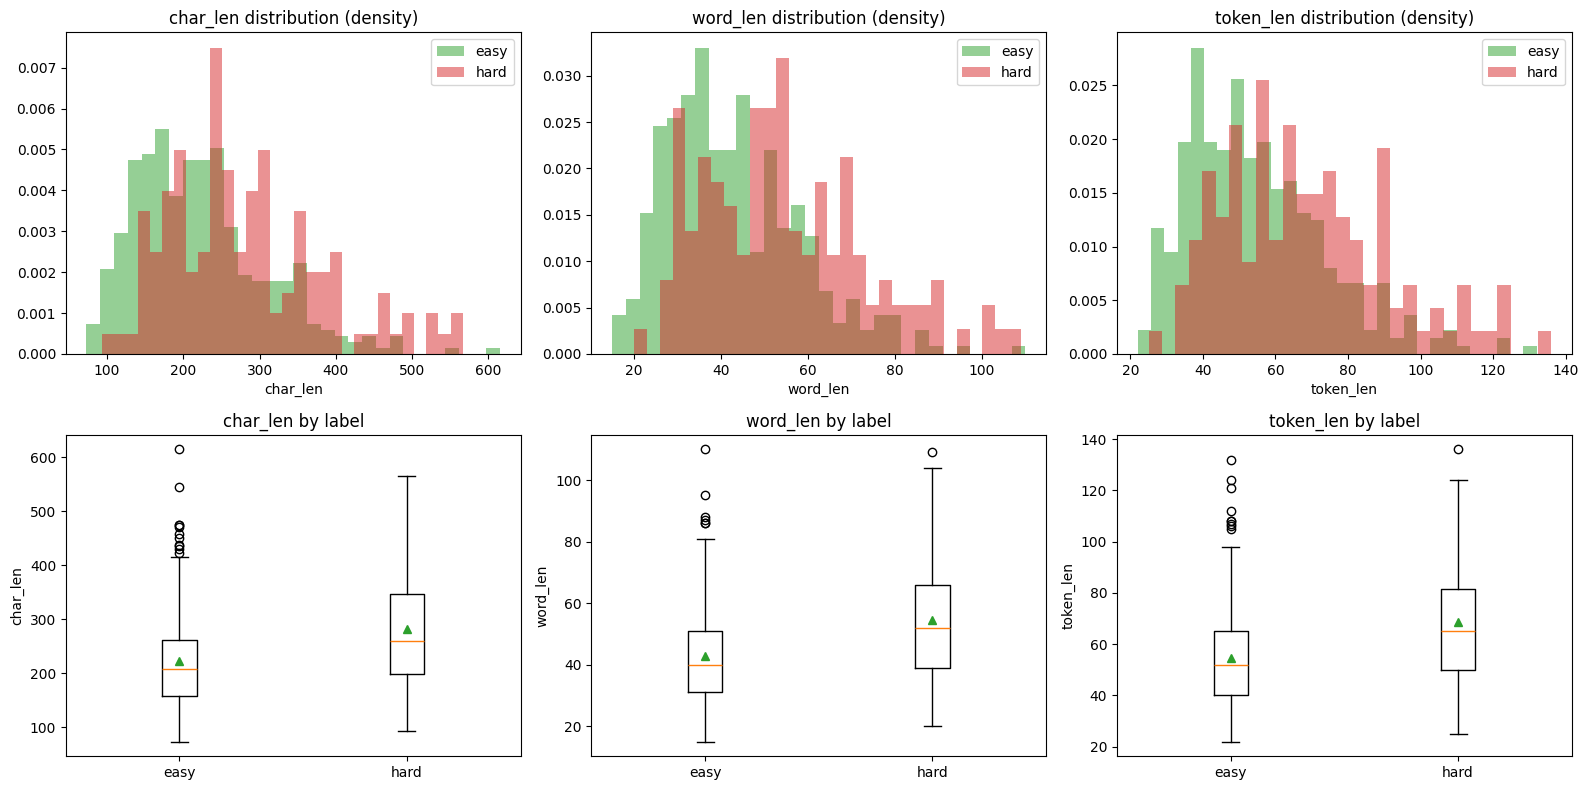

saved -> output_llama_500/length_easy_vs_hard.png


In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
cols = ["char_len", "word_len", "token_len"]

# 위: 히스토그램 (easy/hard 겹쳐 그리기, 밀도 정규화)
for ax, col in zip(axes[0], cols):
    for label, color in [("easy", "tab:green"), ("hard", "tab:red")]:
        sub = len_df[len_df["label"] == label][col]
        ax.hist(sub, bins=30, alpha=0.5, density=True, label=label, color=color)
    ax.set_title(f"{col} distribution (density)")
    ax.set_xlabel(col); ax.legend()

# 아래: 박스플롯
for ax, col in zip(axes[1], cols):
    data = [len_df[len_df["label"] == "easy"][col], len_df[len_df["label"] == "hard"][col]]
    ax.boxplot(data, labels=["easy", "hard"], showmeans=True)
    ax.set_title(f"{col} by label")
    ax.set_ylabel(col)

plt.tight_layout()
plt.savefig("output_llama_500/length_easy_vs_hard.png", dpi=150)
plt.show()
print("saved -> output_llama_500/length_easy_vs_hard.png")

### 8.4 correct_count(0~3)별 평균 길이 추세

이분(easy/hard)이 아니라 정답 횟수(0,1,2,3)에 따라 길이가 단조적으로 변하는지 보면 더 세밀하게 알 수 있다.


               char_len  word_len  token_len
correct_count                               
0                 301.9      58.6       73.4
1                 268.4      52.6       65.9
2                 280.1      53.8       68.2
3                 221.7      42.7       54.7


/tmp/ipykernel_1145333/1053814921.py:10: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1145333/1053814921.py:10: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1145333/1053814921.py:10: UserWarning: Glyph 54943 (\N{HANGUL SYLLABLE HOES}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1145333/1053814921.py:10: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1145333/1053814921.py:10: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1145333/1053814921.py:10: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1145333/1053814921.py:10

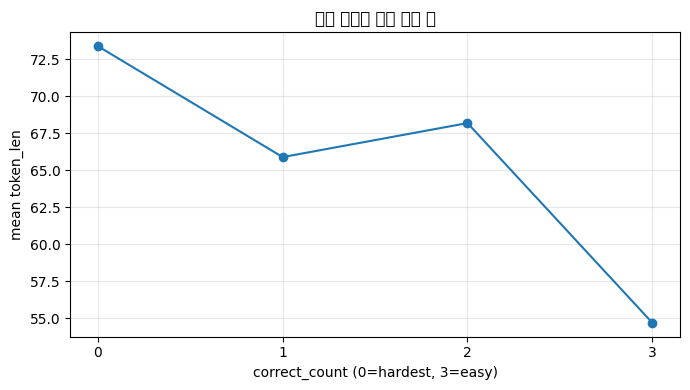

In [14]:
trend = len_df.groupby("correct_count")[["char_len", "word_len", "token_len"]].mean().round(1)
print(trend)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(trend.index, trend["token_len"], marker="o")
ax.set_xlabel("correct_count (0=hardest, 3=easy)")
ax.set_ylabel("mean token_len")
ax.set_title("정답 횟수별 평균 토큰 수")
ax.set_xticks([0, 1, 2, 3]); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()